In [1]:
# A shared apple field. 10 agents. Each round, every agent decides how aggressively to harvest — a number
# between 0 (gentle) and 1 (maximum harvest). The field has a health score that goes up when agents harvest
# gently and goes down when they overharvest. If the field health drops below 30%, all rewards are halved until
# it recovers.
# Trying to make something like that
# sim = CommonsSim(n_agents=10, seed=42)
# obs = sim.reset() # {'field_health': 1.0, 'avg_harvest': 0.0, 'avg_reward': 0.0}
# for round in range(150):
# tax_rate = policymaker.act(obs) # number between 0 and 1
# obs = sim.step(tax_rate)

import numpy as np
from collections import deque
import matplotlib.pyplot as plt

class CommonsSim:
    def __init__(self, n_agents:int = 10, seed: int = 42):
        # if agent is less than 1, raise an error
        if n_agents < 1:
            raise ValueError("Number of agents must be at least 1")
        self.num_agents = n_agents
        self.field_health = 1.0  # Start with a healthy field
        np.random.seed(seed)
        # assigning greedy levels to agents
        self.agent_greed = np.random.rand(n_agents)  # Random greed levels between 0 and 1
        self.avg_harvest = 0.0
        self.avg_reward = 0.0
        # average tax distribution over last 10 rounds
        self.tax_distribution_history = deque(maxlen=10)
        self.tax_distribution_history.append(0.0)  # Start with 0 tax distribution
        # every agent has 2 action options: 0 (harvest gently) and 1 (harvest aggressively)
        #self.action_space = [np.exp(0)/ (np.exp(0) + np.exp(1)), np.exp(1)/ (np.exp(0) + np.exp(1))]# normalized 0 and 1 using softmax
        self.action_space = [0.1, 0.9]
        # temperature parameter for softmax action selection, higher means more exploration
        self.temperature = 0.5
    def reset(self): # reset the environment to the initial state
        self.field_health = 1.0
        self.round = 0
        self.avg_harvest = 0.0
        self.avg_reward = 0.0
        return {'field_health': self.field_health, 'avg_harvest': self.avg_harvest, 'avg_reward': self.avg_reward}
    def step(self, tax_rate: float):
        # Agents choice how much to harvest based on the expected reward that they will get given the action taken
        agents_choice = []
        for agent, greed in enumerate(self.agent_greed):
            # Reward production*(1 - tax_rate) + redistribution 
            production_gently = self.production(agent, 0) * (1 - tax_rate) + np.mean(self.tax_distribution_history) 
            production_aggressive = self.production(agent, 1) * (1 - tax_rate) + np.mean(self.tax_distribution_history)
            # choose action from softmax distribution based on expected reward with greed level as a weight with temperature parameter to control exploration
            action_prob = np.array([np.exp(production_gently / self.temperature), np.exp((production_aggressive+greed) / self.temperature)])  # Add greed to aggressive production
            action_prob = action_prob / np.sum(action_prob)  # Normalize to get probabilities
            action = np.random.choice([0, 1], p=action_prob)
            agents_choice.append(action)
        # agents take action and harvest the field
        harvest_of_agents = [self.production(agent, action) for agent, action in enumerate(agents_choice)]
        total_harvest = sum(harvest_of_agents)
        # tax collected from agents
        tax_collected = total_harvest * tax_rate
        # update tax distribution history
        episode_tax_distribution = tax_collected / self.num_agents  # Distribute tax equally among agents
        self.tax_distribution_history.append(episode_tax_distribution)  # Distribute tax equally among agents
        # update field health based on total mean harvest
        self.avg_harvest = total_harvest / self.num_agents 
        # update field health based on total mean harvest
        if self.avg_harvest > 0.5:  # If average harvest is too high, field health decreases
            self.field_health -= 0.5*(  self.avg_harvest - 0.5)  # Decrease health more if harvest is much higher than 0.5
        else:  # If average harvest is low, field health recovers
            self.field_health += 0.5*(  0.5 - self.avg_harvest)  # Increase health more if harvest is much lower than 0.5
        self.field_health = np.clip(self.field_health, 0, 1)  # Keep health between 0 and 1

        # calculate rewards for agents based on their harvest and tax distribution
        rewards = [harvest * (1 - tax_rate) + episode_tax_distribution for harvest in harvest_of_agents]  
        # if field health drops below 0.3, rewards are halved
        if self.field_health < 0.3:
            rewards = [reward * 0.5 for reward in rewards]
        self.avg_reward = np.mean(rewards)      

        return {'field_health': self.field_health, 'avg_harvest': self.avg_harvest, 'avg_reward': self.avg_reward}

    def production(self, agent:int, action:int):
        # production is based on field health and action they choose(to harvest gently or aggressively)
        production = self.field_health*self.action_space[action]
        return production

In [2]:
sim = CommonsSim(n_agents=10, seed=42)

In [3]:
sim.agent_greed

array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
       0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258])

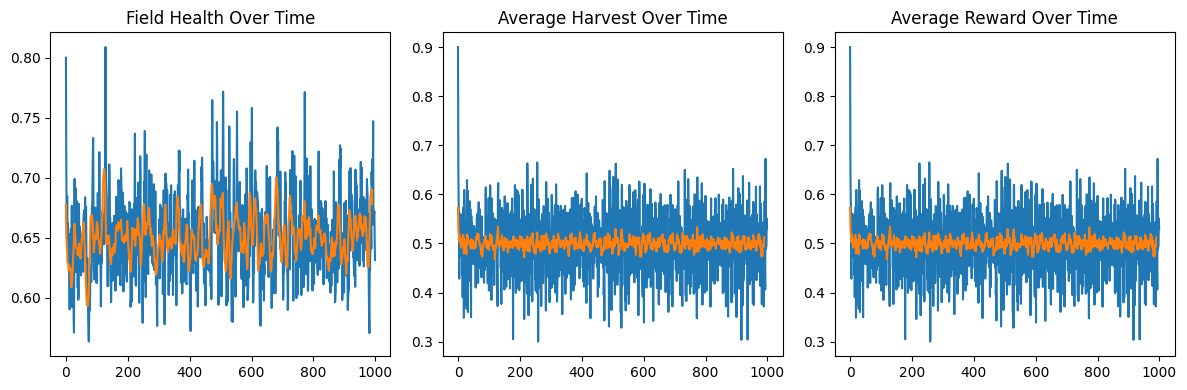

In [4]:
# simulate the for 150 rounds with a random tax policy and plot the results
field_health_history = []
avg_harvest_history = []
avg_reward_history = []

tax_rate_history = []

tax_rate = np.random.rand()  # Random tax rate between 0 and 1
tax_rate_history.append(tax_rate)
for round in range(1000):
    obs = sim.step(tax_rate)
    field_health_history.append(obs['field_health'])
    avg_harvest_history.append(obs['avg_harvest'])
    avg_reward_history.append(obs['avg_reward'])
    # hardcoded tax policy, if field health is below 0.65 increase tax rate, otherwise decrease it [number is experimentally chosen to create some dynamics in the system]
    if obs['field_health'] < 0.65:
        tax_rate = min(tax_rate + 0.01, 1.0)  # Increase tax rate but cap at 1.0
    else:
        tax_rate = max(tax_rate - 0.01, 0.0)  # Decrease tax rate but floor at 0.0
    tax_rate_history.append(tax_rate)

 
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(field_health_history)
# smooth the field_health_history using a moving average with window size of 10
window_size = 10
smoothed_field_health_history = [np.mean(field_health_history[i:i+window_size]) for i in range(len(field_health_history)-window_size+1)]
plt.plot(smoothed_field_health_history)
plt.title('Field Health Over Time')
plt.subplot(1, 3, 2)
plt.plot(avg_harvest_history)
# plot smoothed version of avg_harvest_history using a moving average with window size of 10
smoothed_avg_harvest_history = [np.mean(avg_harvest_history[i:i+window_size]) for i in range(len(avg_harvest_history)-window_size+1)]
plt.plot(smoothed_avg_harvest_history)

plt.title('Average Harvest Over Time')
plt.subplot(1, 3, 3)
plt.plot(avg_reward_history)
plt.title('Average Reward Over Time')
# smooth the avg_reward_history using a moving average with window size of 10
smoothed_avg_reward_history = [np.mean(avg_reward_history[i:i+window_size]) for i in range(len(avg_reward_history)-window_size+1)]
plt.plot(smoothed_avg_reward_history)
plt.tight_layout()

plt.show()


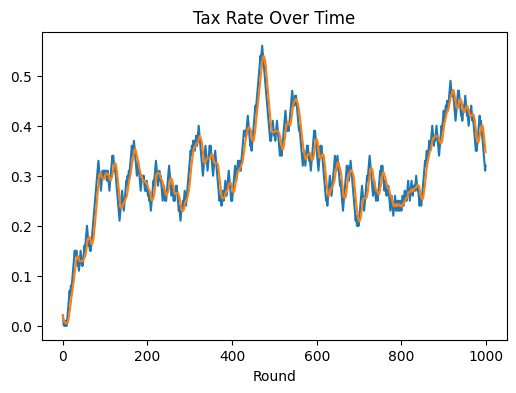

In [14]:
# average tax distribution history
smoothed_tax_distribution_history = [np.mean(list(tax_rate_history[max(0, i-10):i])) for i in range(1, len(tax_rate_history)+1)]
plt.figure(figsize=(6, 4))
plt.plot(tax_rate_history[:-1])  # Exclude the last tax rate which is after the final step
plt.plot(smoothed_tax_distribution_history[:-1])  # Exclude the last tax rate which is after the final step
plt.title('Tax Rate Over Time')
plt.xlabel('Round')
plt.show()

## LLMs as policy maker

In [5]:
model_llama = "meta/llama-3.1-405b-instruct"
model_deepseek = "deepseek-ai/deepseek-v3.2"
model_small =  "meta/llama3-8b-instruct"#"nvidia/llama-3.1-nemotron-nano-4b-v1.1"

In [6]:
from openai import OpenAI
import re
import time
import os
class LLMPolicyMaker:
    def __init__(self, model="meta/llama3-8b-instruct"):
        self.client = OpenAI(
            base_url="https://integrate.api.nvidia.com/v1",
            api_key= os.getenv("NVIDIA_API")
        )
        self.model = model
        self.history = []

        # token tracking
        self.total_input_tokens = 0
        self.total_output_tokens = 0

    # building prompt with context, history, instructions, and query
    def build_prompt(self):
        history_lines = []

        for h in self.history[-5:]:  # last 5 steps only
            history_lines.append(
                f"Tax={h['tax']:.2f} -> Field={h['field']:.2f}, Reward={h['reward']:.2f}, Harvest={h['harvest']:.2f}"
            )

        history_block = "\n".join(history_lines) if history_lines else "None"

        prompt = f"""
        ### CONTEXT

        You are an economic policymaker controlling a shared apple field.

        There are multiple agents harvesting apples each round.

        * Each agent chooses how aggressively to harvest (low or high).
        * High harvesting increases short-term rewards but damages the field.
        * Low harvesting preserves the field but reduces rewards.

        The field has a health value between 0 and 1:

        * If field health drops too low, rewards decrease significantly.
        * If field health stays high, long-term rewards are better.

        You control a tax rate (between 0 and 1):

        * Higher tax discourages aggressive harvesting.
        * Lower tax encourages higher harvesting.

        Your goal is to:

        * Maintain field health at a sustainable level
        * While also keeping agent rewards reasonably high

        Avoid:

        * Field collapse (very low health)
        * Killing incentives (very low rewards)

        ---

        ### HISTORY

        Each entry shows:
        Tax Rate -> Field Health, Average Reward, Average Harvest

        {history_block}

        ---

        ### INSTRUCTIONS

        Based on the history above:

        * Identify how tax rate affects field health and rewards
        * Adjust the tax rate to balance sustainability and reward

        ---

        ### OUTPUT FORMAT (STRICT)

        Return ONLY a number between 0 and 1.

        Do not explain.
        Do not write anything else.

        ---

        ### QUERY

        What should the next tax rate be?

        """
        return prompt

    # number extraction helper[in case LLM returns extra text]
    def extract_number(self, text):
        match = re.search(r"\d*\.?\d+", text)
        return float(match.group()) if match else 0.1

    # action is the tax rate to apply, between 0 and 1
    time.sleep(0.5)  # to avoid hitting rate limits
    def get_action(self):
        prompt = self.build_prompt()

        response = self.client.chat.completions.create(
            model=self.model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.2,
            max_tokens=20
        )

        output = response.choices[0].message.content.strip()

        # token usage for cost estimation
        usage = response.usage
        
        self.total_input_tokens += usage.prompt_tokens
        self.total_output_tokens += usage.completion_tokens
        

        tax = self.extract_number(output)
        tax = max(0.0, min(1.0, tax)) # clamp between 0 and 1

        return tax

  
    def update(self, tax, obs):
        self.history.append({
            "tax": tax,
            "field": obs["field_health"],
            "reward": obs["avg_reward"],
            "harvest": obs["avg_harvest"]
        })

    
    

In [7]:


def simulate_with_LLM(policy, sim, rounds=150):

    obs = sim.reset()

    field_history = []
    reward_history = []
    tax_history = []

    for step in range(rounds):
        # get tax from LLM
        tax = policy.get_action()
        # environment step
        obs = sim.step(tax)
        # update LLM memory
        policy.update(tax, obs)

        # logging
        field_history.append(obs["field_health"])
        reward_history.append(obs["avg_reward"])
        tax_history.append(tax)

    return field_history, reward_history, tax_history, policy.total_input_tokens, policy.total_output_tokens

In [ ]:

# with different random seeds for the environment
print(f"Running simulations with model: {model_llama}")
from tqdm import tqdm
seeds = [42, 43, 44, 45, 46]
results = {}
for seed in tqdm(seeds):
    policy = LLMPolicyMaker(model=model_llama )
    field_history, reward_history, tax_history, input_tokens, output_tokens = simulate_with_LLM(policy, CommonsSim(n_agents=10, seed=seed), rounds=150)
    results[f"{model_llama}_seed_{seed}"] = {
        "field_history": field_history,
        "reward_history": reward_history,
        "tax_history": tax_history,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens
    }
    print(f"Model: {model_llama}, Input Tokens: {input_tokens}, Output Tokens: {output_tokens}")

Running simulations with model: meta/llama-3.1-405b-instruct


  0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
# # save the results to a file
# import json
# with open("simulation_results_llama3_8b_instruct.json", "w") as f:
#     json.dump(results, f)

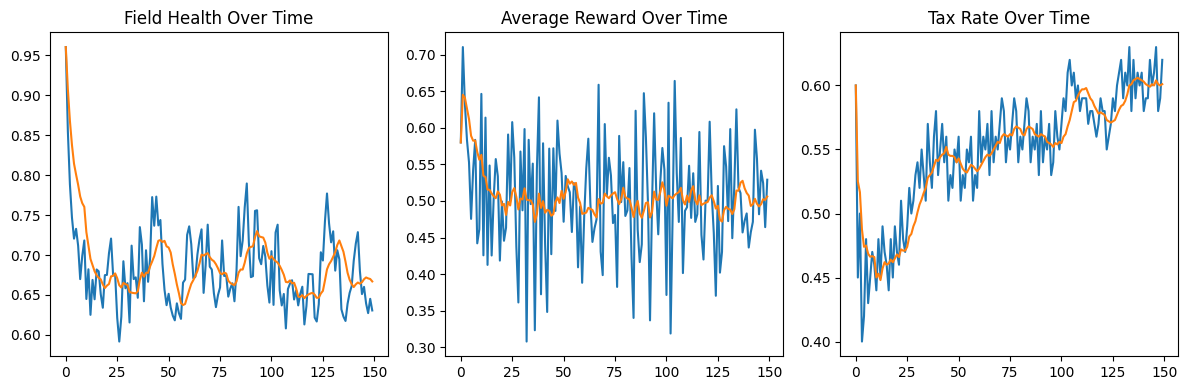

<Figure size 640x480 with 0 Axes>

In [ ]:
# ploting the results for one of the seeds
import matplotlib.pyplot as plt
seed_to_plot = 42
result = results[f"{model_llama}_seed_{seed_to_plot}"]
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(result["field_history"])
plt.plot([np.mean(result["field_history"][max(0, i-10):i]) for i in range(1, len(result["field_history"])+1)])
plt.title('Field Health Over Time')
plt.subplot(1, 3, 2)
plt.plot(result["reward_history"])
plt.plot([np.mean(result["reward_history"][max(0, i-10):i]) for i in range(1, len(result["reward_history"])+1)])
plt.title('Average Reward Over Time')
plt.subplot(1, 3, 3)
plt.plot(result["tax_history"])
plt.plot([np.mean(result["tax_history"][max(0, i-10):i]) for i in range(1, len(result["tax_history"])+1)])
plt.title('Tax Rate Over Time')
plt.tight_layout()
plt.show()


### Comparing results of 2 approaches

In [8]:
# loading the results from a file
import json
with open("simulation_results_llama3_8b_instruct.json", "r") as f:
    results = json.load(f)

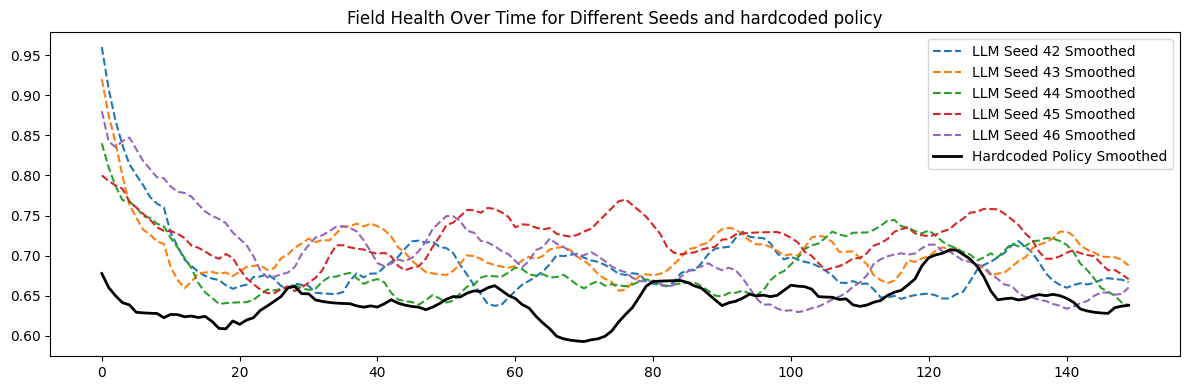

In [13]:
# ploting the results for each seed and comparing them with hardcoded tax policy, on their average field health over time
seeds = [42, 43, 44, 45, 46]
plt.figure(figsize=(12, 4))
for seed in seeds:
    result = results[f"{model_small}_seed_{seed}"]
    plt.plot([np.mean(result["field_history"][max(0, i-10):i]) for i in range(1, len(result["field_history"])+1)], label=f"LLM Seed {seed} Smoothed", linestyle='--')
    
# add the hardcoded tax policy results for comparison
plt.plot(smoothed_field_health_history[:150], label="Hardcoded Policy Smoothed", color='black', linewidth=2)
plt.title('Field Health Over Time for Different Seeds and hardcoded policy')
plt.legend()
plt.tight_layout()
plt.show()


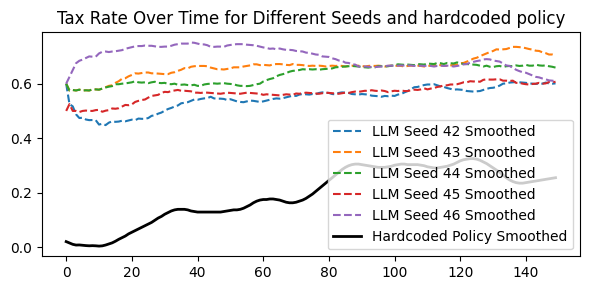

In [26]:
# similarly for tax rate over time
plt.figure(figsize=(6, 3))
for seed in seeds:
    result = results[f"{model_small}_seed_{seed}"]
    plt.plot([np.mean(result["tax_history"][max(0, i-10):i]) for i in range(1, len(result["tax_history"])+1)], label=f"LLM Seed {seed} Smoothed", linestyle='--')
# add the hardcoded tax policy results for comparison
plt.plot([np.mean(tax_rate_history[max(0, i-10):i]) for i in range(1, len(tax_rate_history[:150])+1)], label="Hardcoded Policy Smoothed", color='black', linewidth=2)
plt.title('Tax Rate Over Time for Different Seeds and hardcoded policy')
plt.legend()
plt.tight_layout()
plt.show()

Seed 42: Average Field Health in Last 50 Rounds: 0.67
Seed 43: Average Field Health in Last 50 Rounds: 0.70
Seed 44: Average Field Health in Last 50 Rounds: 0.70
Seed 45: Average Field Health in Last 50 Rounds: 0.71
Seed 46: Average Field Health in Last 50 Rounds: 0.67
Hardcoded Policy: Average Field Health in Last 50 Rounds: 0.66


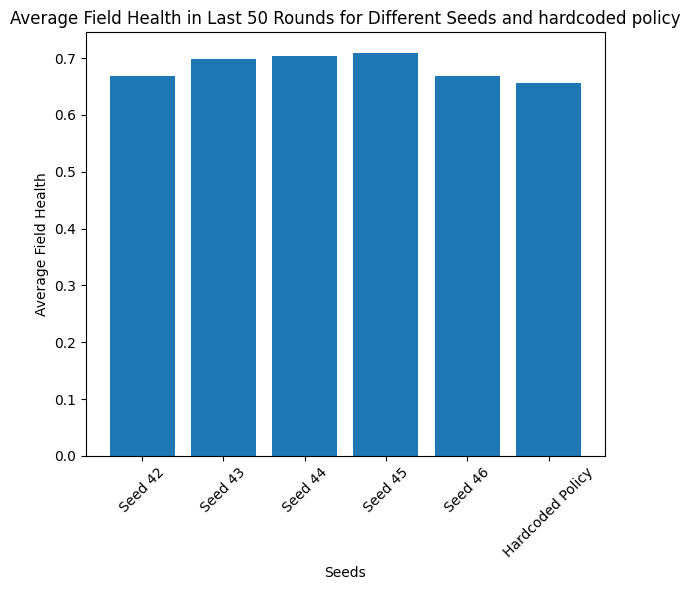

In [31]:
# average field health of last 50 rounds for each seed bar plot
avg_field_healths = []
for seed in seeds:
    result = results[f"{model_small}_seed_{seed}"]
    avg_field_health_last_50 = np.mean(result["field_history"][-50:])
    avg_field_healths.append(avg_field_health_last_50)
    print(f"Seed {seed}: Average Field Health in Last 50 Rounds: {avg_field_health_last_50:.2f}")

# add the hardcoded policy average field health for last 100 to 150 rounds
hardcoded_avg_field_health = np.mean(smoothed_field_health_history[100:150])
avg_field_healths.append(hardcoded_avg_field_health)
print(f"Hardcoded Policy: Average Field Health in Last 50 Rounds: {hardcoded_avg_field_health:.2f}")
plt.figure(figsize=(6, 6))
plt.bar([f"Seed {seed}" for seed in seeds] + ["Hardcoded Policy"], avg_field_healths)
plt.title('Average Field Health in Last 50 Rounds for Different Seeds and hardcoded policy')
plt.xlabel('Seeds')
plt.ylabel('Average Field Health')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



<BarContainer object of 2 artists>

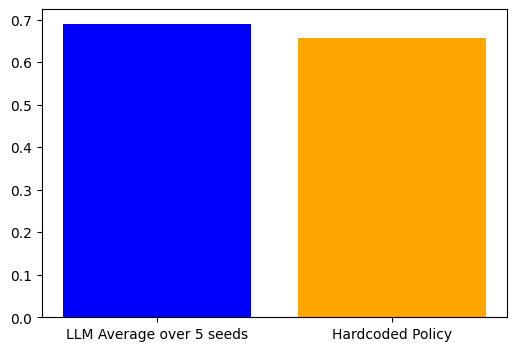

In [20]:
# average over all seeds for field health for last 50 rounds vs hardcoded policy
avg_over_seeds_avg_field_health = np.mean(avg_field_healths[:-1])  # exclude hardcoded policy
hardcoded_avg_field_health = avg_field_healths[-1]
plt.figure(figsize=(6, 4))
plt.bar(["LLM Average over 5 seeds", "Hardcoded Policy"], [avg_over_seeds_avg_field_health, hardcoded_avg_field_health], color=['blue', 'orange'])

In [32]:
print(f"Average over 5 seeds: {avg_over_seeds_avg_field_health:.2f}, Hardcoded Policy: {hardcoded_avg_field_health:.2f}")

Average over 5 seeds: 0.69, Hardcoded Policy: 0.66


### API cost estimation

In [21]:
model_small

'meta/llama3-8b-instruct'

In [22]:
api_input_tokens = [results[f"{model_small}_seed_{seed}"]["input_tokens"] for seed in seeds]
api_output_tokens = [results[f"{model_small}_seed_{seed}"]["output_tokens"] for seed in seeds]

In [ ]:
# input token and output token are same for each seed, so we will take the first one as representative
print(f"Model: {model_small}, Input Tokens: {api_input_tokens[0]}, Output Tokens: {api_output_tokens[0]}")
# as per the documentation (https://build.nvidia.com/meta/llama-3_1-8b-instruct/deploy), per million tokens for both input and output cost is $0.22

[63992, 63992, 63992, 63992, 63992]

In [ ]:
cost = (api_input_tokens[0] + api_output_tokens[0]) / 1_000_000 * 0.22
print(f"Estimated Cost for 150 rounds for each seed: ${cost:.4f}")

Estimated Cost for 150 rounds: $0.0142
